In [ ]:
# !pip install datasets==2.16.1

In [5]:
import random
import re
from typing import List
import tqdm

from datasets import load_dataset, list_datasets, Dataset
from IPython.display import Image
from IPython.core.display import HTML
import torch
import torch.nn as nn
import torch.nn.functional as F
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2Model, GPT2Tokenizer, GPT2LMHeadModel
from tqdm import tqdm

https://huggingface.co/docs/transformers/model_doc/gpt2

https://huggingface.co/docs/transformers/main_classes/tokenizer

In [6]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("cpu")
print(f"Our device is {DEVICE}")

Our device is cuda:0


# Задание 1: интерпретируем attention

Вам даны attention-скоры для последовательности ниже. Необходимо определить позицию токена, на который больше всего "обращал внимание" токен на позиции 4 во второй attention head на последнем слое модели *(все вышеупомянутые числа- индексы!)* . Ответом должен быть индекс

In [3]:
tokenizer = GPT2Tokenizer.from_pretrained('openai-community/gpt2')
model = GPT2LMHeadModel.from_pretrained('openai-community/gpt2', output_attentions=True)
model.eval()

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
model_input = tokenizer("The quick brown fox jumps over the lazy dog.", return_tensors='pt')
model_input

{'input_ids': tensor([[  464,  2068,  7586, 21831, 18045,   625,   262, 16931,  3290,    13]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

[Документация](https://huggingface.co/docs/transformers/v4.45.1/en/model_doc/gpt2#transformers.GPT2LMHeadModel.forward) к модели

In [6]:
"""
YOUR IMPLEMENTAION HERE
"""

'\nYOUR IMPLEMENTAION HERE\n'

### Ответ

In [8]:
outputs = model(**model_input)
attn_layers = outputs.attentions

layer_idx = 0
head_idx = 2

attn_tensor = attn_layers[layer_idx]
attn_head = attn_tensor[0, head_idx]

attn_head_np = attn_head.detach().cpu().numpy()

token_index = 4
attention_to_others = attn_head_np[token_index] 

print(f"Attention of token #{token_index} ('{tokenizer.decode([model_input['input_ids'][0][token_index]])}') "
      f"is distributed over the sequence as follows:")
for i, score in enumerate(attention_to_others):
    print(f"  -> token #{i} ('{tokenizer.decode([model_input['input_ids'][0][i]])}'): {score:.4f}")

Attention of token #4 (' jumps') is distributed over the sequence as follows:
  -> token #0 ('The'): 0.4232
  -> token #1 (' quick'): 0.3105
  -> token #2 (' brown'): 0.1752
  -> token #3 (' fox'): 0.0306
  -> token #4 (' jumps'): 0.0605
  -> token #5 (' over'): 0.0000
  -> token #6 (' the'): 0.0000
  -> token #7 (' lazy'): 0.0000
  -> token #8 (' dog'): 0.0000
  -> token #9 ('.'): 0.0000


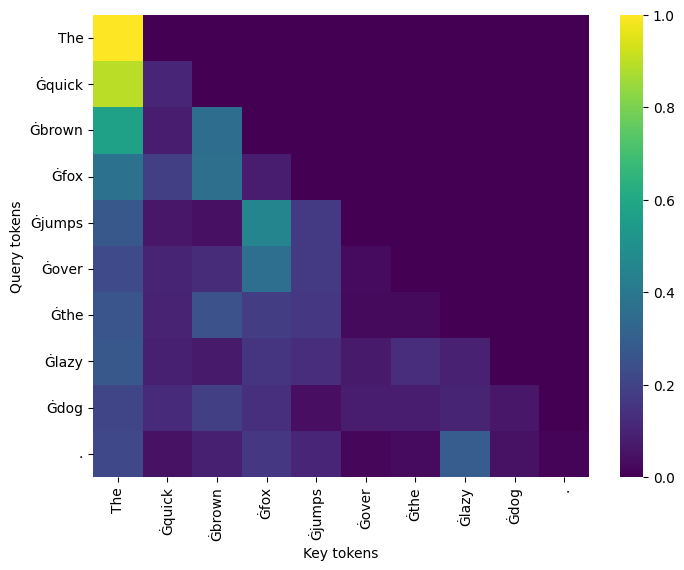

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
layer = 0
head = 0
attention_matrix = attn_layers[layer][0, head].detach().cpu().numpy()

tokens = tokenizer.convert_ids_to_tokens(model_input["input_ids"][0])
plt.figure(figsize=(8, 6))
sns.heatmap(attention_matrix, xticklabels=tokens, yticklabels=tokens, cmap="viridis")
plt.xlabel("Key tokens")
plt.ylabel("Query tokens")
plt.show()

# Как работает генерация с т.з. кода под капотом:

In [8]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")

In [ ]:
TEXT_INPUT = "Between the cup and the lip a morsel may "

In [46]:
inputs = tokenizer(TEXT_INPUT, return_tensors="pt")

In [47]:
for k, v in inputs.items():
  inputs[k] = v.to(DEVICE)

In [48]:
bare_model = GPT2Model.from_pretrained("gpt2")
bare_model.eval()
bare_model.to(DEVICE)
bare_outputs = bare_model(**inputs, output_hidden_states=True)

In [49]:
bare_model

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [50]:
last_hidden_states = bare_outputs.last_hidden_state

Weight tying

In [51]:
Image(url= "https://lena-voita.github.io/resources/lectures/lang_models/practical/weight_tying_idea-min.png", width=1900, height=900)

In [52]:
logits = torch.matmul(
    last_hidden_states[-1][-1],
    bare_model.wte.weight.T
)

In [53]:
bare_probas = F.softmax(logits, dim=0)

In [54]:
torch.argmax(bare_probas)

tensor(307, device='cuda:0')

In [55]:
tokenizer.decode([torch.argmax(bare_probas)])

' be'

# Упрощённая генерация:

In [56]:
llm_model = AutoModelForCausalLM.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)
llm_model.eval()
llm_model.to(DEVICE)
llm_outputs = llm_model(**inputs)

In [ ]:
n_params = 0
for param in llm_model.parameters(recurse=True):
    n_params += param.numel()


n_params = str(n_params)
n_params = ",".join(
    [
        n_params[i: i+3]
        for i in range(
            len(n_params) - 3, -1, -3
        )
    ][::-1]
)
print(f"Number of parameters: {n_params}")

Number of parameters: 124,439,808


In [58]:
torch.argmax(llm_outputs.logits[-1][-1])

tensor(307, device='cuda:0')

In [59]:
llm_probas = F.softmax(llm_outputs.logits[-1][-1], dim=0)

In [60]:
torch.allclose(bare_probas, llm_probas, rtol=1e-4)

True

# Задание 2: написать fine-tuning для языковой модели под набор данных:

Описание датасета можно найти тут: \
https://paperswithcode.com/dataset/rucos \
https://huggingface.co/datasets/RussianNLP/russian_super_glue

In [10]:
dataset = load_dataset("RussianNLP/russian_super_glue", name='rucos')

/home/unicornred/python_env/torch_gpu/lib64/python3.13/site-packages/datasets/load.py:1429: FutureWarning: The repository for RussianNLP/russian_super_glue contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/RussianNLP/russian_super_glue
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


In [11]:
RE_BAD_PATTERNS = re.compile("(@[a-z]+|\n)")

In [12]:
random_idx_from_train = random.randint(0, len(dataset['train']) - 1)

random_object = dataset['train'][random_idx_from_train]['passage']

filtered_random_object = RE_BAD_PATTERNS.sub(" ", random_object)
print(random_object)
print("*" * 20)
print(filtered_random_object)

Трибунал ООН в Гамбурге обязал Москву позволить активистам "Гринпис" с судна Arctic Sunrise покинуть территорию России. Репортаж DW из зала суда. Второе заседание Международного трибунала по морскому праву, касавшееся жалобы Нидерландов на действия России в отношении судна Arctic Sunrise и находившихся на его борту активистов экологической организации "Грипис" состоялось в Гамбурге 22 ноября и длилось недолго. Решение по делу председатель трибунала Сюндзи Янаи зачитывал 35 минут, периодически прерываясь, чтобы сделать глоток воды. За это время четверо представителей голландского МИДа, который в конце октября подал жалобу против России, несколько раз переглядывались и одобрительно кивали. Вскоре последовали рукопожатия и объятия: трибунал удовлетворил требования Гааги и обязал российские власти немедленно освободить судно Arctic Sunrise и всех задержанных активистов в обмен на финансовые гарантии со стороны Нидерландов в размере 3,6 млн евро.
@highlight
В Швеции задержаны двое граждан Р

In [13]:
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.add_special_tokens({'pad_token': "<|endoftext|>"})

def texts_to_batch(texts: List[str]) -> torch.Tensor:
    clean_texts = [
        RE_BAD_PATTERNS.sub(" ", _["passage"]) for _ in texts
    ]
    tokenized_texts = tokenizer(
        text=clean_texts,
        return_tensors="pt",
        add_special_tokens=True,
        padding="max_length",
        truncation=True
      )
    return tokenized_texts

In [14]:
BATCH_SIZE = 4

train_dl = torch.utils.data.DataLoader(
    dataset=dataset['train'],
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=texts_to_batch
)

In [15]:
N_ITERATIONS = 1000

inputs = tokenizer("В прошлый четверг президенты Казахстана и России", return_tensors="pt")
for k, v in inputs.items():
    inputs[k] = v.to(DEVICE)

In [16]:
OUTPUT_SIZE = 40

In [17]:
llm_model = AutoModelForCausalLM.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)
llm_model.eval()
llm_model.to(DEVICE)
llm_outputs = llm_model(**inputs)

In [18]:
print(tokenizer.decode(torch.argmax(llm_outputs.logits, dim=2)[0], skip_special_tokens=True))


поос�ие й �с�тсеер го�род�д�ени � паздн� �твни п посси� �


In [ ]:
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params=llm_model.parameters(), lr=1e-6
)

EPOCHS = 1

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    pbar = tqdm(train_dl, desc="Training")
    cur_iteration = 0

    llm_model.train()

    for batch in pbar:
        # if cur_iteration == N_ITERATIONS:
        #     break
    
        batch_input = {k: v.to(DEVICE) for k, v in batch.items()}
            
        outputs = llm_model(**batch_input, labels=batch["input_ids"])
        loss_value = outputs.loss

        loss_value.backward()
        optimizer.step()
        
        cur_iteration += 1

    llm_model.eval()
    print(f"Loss value: {loss_value.item()}")


Epoch 1/1


Training: 100%|██████████| 18048/18048 [1:04:35<00:00,  4.66it/s]

Loss value: 1.203076720237732


In [15]:
for n_beams in range(2, 5):
    beam_output = llm_model.generate(**inputs, max_new_tokens=OUTPUT_SIZE, num_beams=n_beams, pad_token_id=tokenizer.eos_token_id)
    print(f"Beam size={n_beams}")
    print(tokenizer.decode(beam_output[0], skip_special_tokens=True))
    print()

print("*" * 20)

Beam size=2
В прошлый четверг президенты Казахстана и России президента Казахстана президента Ка

Beam size=3
В прошлый четверг президенты Казахстана и России президента Казахстана президента Ка

Beam size=4
В прошлый четверг президенты Казахстана и России президента Казахстана президента Ка

********************


# Задание 3: написать greedy search, сравнить результаты с имплементацией от transformers

In [19]:
OUTPUT_SIZE = 40

In [24]:
inputs = tokenizer("В прошлый четверг президенты Казахстана и России", return_tensors="pt").to(DEVICE)

In [25]:
llm_model = AutoModelForCausalLM.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)
llm_model.eval()
llm_model.to(DEVICE)
llm_outputs = llm_model(**inputs)

In [ ]:
def convert_to_expected_input(input_ids, attention_mask):
    input_ids = torch.tensor(input_ids, device=DEVICE)
    attention_mask = torch.tensor(attention_mask, device=DEVICE)
    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

In [30]:
input_ids, attention_mask = inputs["input_ids"], inputs["attention_mask"]
"""
input_ids должно содержать нагенерированные токены
"""
generated = input_ids.clone()

for _ in range(OUTPUT_SIZE):
    outputs = llm_model(generated)
    next_token_logits = outputs.logits[:, -1, :] 

    next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(0)

    generated = torch.cat((generated, next_token_id), dim=1)

print(tokenizer.decode(generated.squeeze().tolist(), skip_special_tokens=True))

В прошлый четверг президенты Казахстана и России прошлый четверг президенты Казах


In [33]:
llm_predictions = llm_model.generate(**inputs, max_new_tokens=OUTPUT_SIZE)
print(tokenizer.decode(llm_predictions.squeeze().tolist(), skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


В прошлый четверг президенты Казахстана и России прошлый четверг президенты Казах


Ниже проверяем, что наивная имплементация совпадает с ожидаемой:

In [42]:
assert generated[-1][-OUTPUT_SIZE:].tolist() == llm_predictions[-1][-OUTPUT_SIZE:].tolist()

In [43]:
tokenizer.decode(llm_predictions[0], skip_special_tokens=True)

'В прошлый четверг президенты Казахстана и России прошлый четверг президенты Казах'